In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Sales.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Sales.csv'

In [3]:
import os

os.getcwd()

'C:\\Users\\deepl\\Loan_Approval_Project'

In [4]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Loan_Approval_Project.ipynb',
 'loan_data.csv',
 'Sales.csv',
 'Untitled.ipynb']

In [5]:
df = pd.read_csv("Sales.csv")

In [6]:
df.head()

,Order_ID,Date,Product,Category,Region,Quantity_Sold,Unit_Price,Discount,Sales
0,1000,2024-01-01,Mobile,Electronics,South,1,22000,10,19800.0
1,1001,2024-01-02,Smartwatch,Wearables,North,5,5000,0,25000.0
2,1002,2024-01-03,Mouse,Accessories,North,2,800,0,1600.0
3,1003,2024-01-04,Smartwatch,Wearables,South,8,5000,0,40000.0
4,1004,2024-01-05,Mouse,Accessories,East,8,800,15,5440.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   int64  
 1   Date           1000 non-null   object 
 2   Product        1000 non-null   object 
 3   Category       1000 non-null   object 
 4   Region         1000 non-null   object 
 5   Quantity_Sold  1000 non-null   int64  
 6   Unit_Price     1000 non-null   int64  
 7   Discount       1000 non-null   int64  
 8   Sales          1000 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 70.4+ KB


In [8]:
df.isnull().sum()

Order_ID         0
Date             0
Product          0
Category         0
Region           0
Quantity_Sold    0
Unit_Price       0
Discount         0
Sales            0
dtype: int64

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   int64         
 1   Date           1000 non-null   datetime64[ns]
 2   Product        1000 non-null   object        
 3   Category       1000 non-null   object        
 4   Region         1000 non-null   object        
 5   Quantity_Sold  1000 non-null   int64         
 6   Unit_Price     1000 non-null   int64         
 7   Discount       1000 non-null   int64         
 8   Sales          1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 70.4+ KB


In [11]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [12]:
df.head()

,Order_ID,Date,Product,Category,Region,Quantity_Sold,Unit_Price,Discount,Sales,Year,Month,Day
0,1000,2024-01-01,Mobile,Electronics,South,1,22000,10,19800.0,2024,1,1
1,1001,2024-01-02,Smartwatch,Wearables,North,5,5000,0,25000.0,2024,1,2
2,1002,2024-01-03,Mouse,Accessories,North,2,800,0,1600.0,2024,1,3
3,1003,2024-01-04,Smartwatch,Wearables,South,8,5000,0,40000.0,2024,1,4
4,1004,2024-01-05,Mouse,Accessories,East,8,800,15,5440.0,2024,1,5


In [13]:
df.describe()

,Order_ID,Date,Quantity_Sold,Unit_Price,Discount,Sales,Year,Month,Day
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,1499.500000,2024-10-29 09:36:00,10.467000,14672.100000,7.700000,1.366634e+05,2024.364000,6.090000,15.670000
min,1000.000000,2024-01-01 00:00:00,1.000000,800.000000,0.000000,7.200000e+02,2024.000000,1.000000,1.000000
25%,1249.750000,2024-05-04 18:00:00,5.000000,1500.000000,5.000000,1.440000e+04,2024.000000,3.000000,8.000000
50%,1499.500000,2024-09-06 12:00:00,11.000000,5000.000000,10.000000,4.860000e+04,2024.000000,6.000000,16.000000
75%,1749.250000,2025-04-24 06:00:00,15.000000,22000.000000,15.000000,1.870000e+05,2025.000000,9.000000,23.000000
max,1999.000000,2025-12-30 00:00:00,20.000000,55000.000000,15.000000,1.100000e+06,2025.000000,12.000000,31.000000
std,288.819436,NaN,5.721857,17360.123429,5.602802,1.953682e+05,0.481389,3.304667,8.777593


In [14]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

Product
Laptop        62991500.0
Mobile        28381100.0
Tablet        20026800.0
Monitor       13927800.0
Smartwatch     5910500.0
Headphones     2568100.0
Keyboard       1839900.0
Mouse          1017680.0
Name: Sales, dtype: float64

In [15]:
df.groupby("Region")["Sales"].sum()

Region
East     31599820.0
North    29861850.0
South    40109285.0
West     35092425.0
Name: Sales, dtype: float64

In [16]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
1     11553245.0
2     12390455.0
3     14157460.0
4     11405980.0
5     12541800.0
6     13916050.0
7     13518360.0
8     12785190.0
9      9531940.0
10     6160865.0
11     8482240.0
12    10219795.0
Name: Sales, dtype: float64

Matplotlib is building the font cache; this may take a moment.


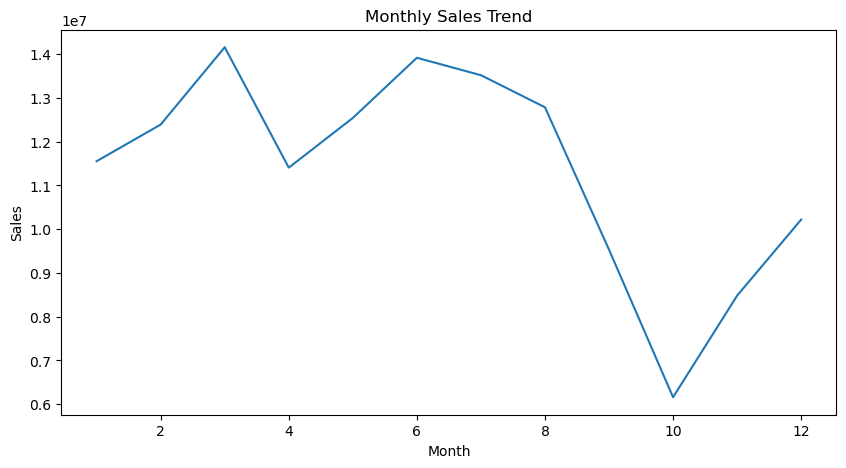

In [17]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

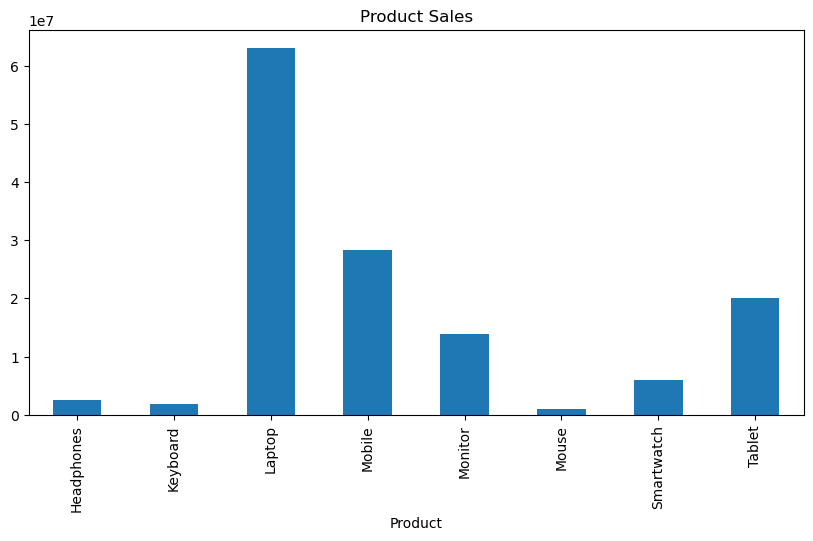

In [18]:
df.groupby("Product")["Sales"].sum().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Product Sales")
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

le_product = LabelEncoder()
le_category = LabelEncoder()
le_region = LabelEncoder()

df["Product"] = le_product.fit_transform(df["Product"])

df["Category"] = le_category.fit_transform(df["Category"])

df["Region"] = le_region.fit_transform(df["Region"])

In [21]:
X = df[
    [
        "Product",
        "Category",
        "Region",
        "Quantity_Sold",
        "Unit_Price",
        "Discount",
        "Year",
        "Month",
        "Day"
    ]
]

y = df["Sales"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
predictions = model.predict(X_test)

predictions[:10]

array([  7539.2 , 204744.  ,  59910.  ,  14509.5 ,   4715.  ,  79794.  ,
        13884.8 , 176850.  ,  15873.75, 416377.5 ])

In [26]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 5899.5925
R2 Score: 0.9963224287962527


In [27]:
import joblib

joblib.dump(model, "sales_model.pkl")

['sales_model.pkl']

In [28]:
model.predict(
    [[
        4,      # Product
        1,      # Category
        2,      # Region
        10,     # Quantity
        22000,  # Price
        5,      # Discount
        2025,
        6,
        15
    ]]
)

D:\Games\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([205130.])

In [1]:
import os

os.getcwd()

'C:\\Users\\deepl'

In [1]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

NameError: name 'y_test' is not defined

In [2]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

NameError: name 'y_test' is not defined

In [3]:
accuracy = r2_score(y_test, y_pred) * 100
print(f"Model Accuracy: {accuracy:.2f}%")

NameError: name 'r2_score' is not defined

In [4]:
model = joblib.load("sales_model.pkl")

NameError: name 'joblib' is not defined

In [5]:
train_score = model.score(X_train, y_train)

NameError: name 'model' is not defined

In [6]:
pip install pandas scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import joblib

# Load model
model = joblib.load("sales_model.pkl")

# Load dataset
df = pd.read_csv("Sales.csv")

print(df.head())

   Order_ID        Date     Product     Category Region  Quantity_Sold  \
0      1000  2024-01-01      Mobile  Electronics  South              1   
1      1001  2024-01-02  Smartwatch    Wearables  North              5   
2      1002  2024-01-03       Mouse  Accessories  North              2   
3      1003  2024-01-04  Smartwatch    Wearables  South              8   
4      1004  2024-01-05       Mouse  Accessories   East              8   

   Unit_Price  Discount    Sales  
0       22000        10  19800.0  
1        5000         0  25000.0  
2         800         0   1600.0  
3        5000         0  40000.0  
4         800        15   5440.0  


In [8]:
print(df.columns.tolist())

['Order_ID', 'Date', 'Product', 'Category', 'Region', 'Quantity_Sold', 'Unit_Price', 'Discount', 'Sales']


In [9]:
target = "Sales"  # replace with actual target column

X = df.drop(columns=[target])
y = df[target]

In [10]:
from sklearn.preprocessing import LabelEncoder

for col in ["Product", "Category", "Region"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [11]:
y_pred = model.predict(X)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Date
- Order_ID
Feature names seen at fit time, yet now missing:
- Day
- Month
- Year


In [12]:
X = X.drop(columns=['Order_ID'])

In [13]:
X['Date'] = pd.to_datetime(X['Date'])

X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['Day'] = X['Date'].dt.day

X = X.drop(columns=['Date'])

In [14]:
X = X[
    [
        'Product',
        'Category',
        'Region',
        'Quantity_Sold',
        'Unit_Price',
        'Discount',
        'Year',
        'Month',
        'Day'
    ]
]

In [15]:
print(X.columns.tolist())

['Product', 'Category', 'Region', 'Quantity_Sold', 'Unit_Price', 'Discount', 'Year', 'Month', 'Day']


In [16]:
y_pred = model.predict(X)

In [17]:
print(df.columns.tolist())

['Order_ID', 'Date', 'Product', 'Category', 'Region', 'Quantity_Sold', 'Unit_Price', 'Discount', 'Sales']


In [18]:
y = df['Sales']

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.9989902125833748
MAE: 2820.6142999999997
RMSE: 6205.14074820064


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = model.predict(X_test)

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.9963224287962527
MAE: 5899.5925
RMSE: 10676.184907632032
